# 🌍 Analyse des anomalies de température mondiale

## Exploration et préparation des données

Ce notebook présente l'exploration et la préparation de données climatiques issues de la NASA, dans le cadre d'un projet d'analyse de l'évolution des températures terrestres.

Les données étudiées comprennent notamment les anomalies de température LOTI (Land-Ocean Temperature Index) ainsi que les données AIRS.

In [1]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

LOTI = Anomalies combinées de température de l'air et de l'eau de surface terrestre et de surface de la mer. C’est-à-dire les écarts de l'indice de température Land-Océan (LOTI) par rapport aux moyens 1951-1980

In [2]:
path_loti = '../data/loti_temperature_anomalies.csv'
df_loti = pd.read_csv(path_loti, header = 0, index_col = "Year")
df_loti.head()

,Glob,NHem,SHem,24N-90N,24S-24N,90S-24S,64N-90N,44N-64N,24N-44N,EQU-24N,24S-EQU,44S-24S,64S-44S,90S-64S
Year,,,,,,,,,,,,,,
1880,-0.18,-0.30,-0.05,-0.40,-0.14,-0.02,-0.81,-0.53,-0.30,-0.16,-0.11,-0.04,0.05,0.69
1881,-0.10,-0.20,0.00,-0.37,0.09,-0.07,-0.92,-0.49,-0.21,0.09,0.10,-0.06,-0.07,0.61
1882,-0.12,-0.23,-0.01,-0.33,-0.06,0.01,-1.41,-0.30,-0.17,-0.06,-0.05,0.01,0.04,0.64
1883,-0.18,-0.29,-0.07,-0.36,-0.17,-0.01,-0.18,-0.57,-0.27,-0.19,-0.16,-0.04,0.07,0.52
1884,-0.29,-0.44,-0.15,-0.62,-0.15,-0.14,-1.31,-0.66,-0.48,-0.14,-0.17,-0.19,-0.02,0.67


AIRS v7 = AIRS (Atmospheric Infrared Sounder) est un instrument infrarouge embarqué sur le satellite Aqua de la NASA. v7 fait référence à la mises à jour des algorithmes de traitement des données

GHCNv4/ERSSTv5 =
  GHCNv4, Base de données mondiale de températures de surface mesurées par des stations météorologiques terrestres (villes, aéroports, etc.). Elle est gérée par la NOAA (agence météorologique américaine). Elle sert à analyser les températures sur les continents sur de longues périodes.

  ERSSTv5, Jeu de données qui reconstitue les températures de surface des océans (SST = Sea Surface Temperature). Il sert à étudier les températures des mers et océans, même dans les zones peu ou pas mesurées directement.




In [3]:
path_airs = "../data/airs_temperature_anomalies.csv"
df_airs = pd.read_csv(path_airs, header = 1, index_col = "Year")
df_airs.head()

,Glob,N.Hemi,S.Hemi,24N-90N,24S-24N,90S-24S,64N-90N,44N-64N,24N-44N,EQU-24N,24S-EQU,44S-24S,64S-44S,90S-64S
Year,,,,,,,,,,,,,,
2003,-0.134,-0.293,0.026,-0.465,-0.006,0.028,-1.184,-0.248,-0.369,-0.035,0.022,-0.126,0.164,0.220
2004,-0.181,-0.263,-0.099,-0.391,-0.119,-0.054,-1.303,-0.238,-0.188,-0.072,-0.165,-0.094,0.026,-0.095
2005,-0.021,-0.066,0.024,-0.121,0.024,0.018,-0.292,0.123,-0.227,0.017,0.032,-0.145,0.034,0.478
2006,-0.080,-0.080,-0.080,-0.090,-0.107,-0.034,-0.191,-0.070,-0.070,-0.066,-0.148,-0.090,-0.038,0.142
2007,-0.063,-0.050,-0.076,0.011,-0.133,-0.044,0.022,0.155,-0.089,-0.142,-0.124,-0.124,-0.111,0.331


In [4]:
df_loti.info()

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 1880 to 2025
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Glob     146 non-null    float64
 1   NHem     146 non-null    float64
 2   SHem     146 non-null    float64
 3   24N-90N  146 non-null    float64
 4   24S-24N  146 non-null    float64
 5   90S-24S  146 non-null    float64
 6   64N-90N  146 non-null    float64
 7   44N-64N  146 non-null    float64
 8   24N-44N  146 non-null    float64
 9   EQU-24N  146 non-null    float64
 10  24S-EQU  146 non-null    float64
 11  44S-24S  146 non-null    float64
 12  64S-44S  146 non-null    float64
 13  90S-64S  146 non-null    float64
dtypes: float64(14)
memory usage: 16.1 KB


In [5]:
rename_loti_columns = {
    "24N-90N": "N. Extratropics",
    "24S-24N": "Tropics",
    "90S-24S": "S. Extratropics",
    "64N-90N": "Arctic",
    "44N-64N": "N. Temperate",
    "24N-44N": "N. Subtropics",
    "EQU-24N": "N. Tropics",
    "24S-EQU": "S. Tropics",
    "44S-24S": "S. Subtropics",
    "64S-44S": "S. Temperate",
    "90S-64S": "Antarctic"
}

df_loti = df_loti.rename(columns=rename_loti_columns)

df_loti.columns

Index(['Glob', 'NHem', 'SHem', 'N. Extratropics', 'Tropics', 'S. Extratropics',
       'Arctic', 'N. Temperate', 'N. Subtropics', 'N. Tropics', 'S. Tropics',
       'S. Subtropics', 'S. Temperate', 'Antarctic'],
      dtype='str')

In [6]:
df_airs.info()

<class 'pandas.DataFrame'>
Index: 73 entries, 2003 to 2025
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Glob     71 non-null     str  
 1   N.Hemi   71 non-null     str  
 2   S.Hemi   71 non-null     str  
 3   24N-90N  71 non-null     str  
 4   24S-24N  71 non-null     str  
 5   90S-24S  71 non-null     str  
 6   64N-90N  71 non-null     str  
 7   44N-64N  71 non-null     str  
 8   24N-44N  71 non-null     str  
 9   EQU-24N  71 non-null     str  
 10  24S-EQU  71 non-null     str  
 11  44S-24S  71 non-null     str  
 12  64S-44S  71 non-null     str  
 13  90S-64S  71 non-null     str  
dtypes: str(14)
memory usage: 8.6+ KB


In [7]:
rename_airs_columns = {
    "N.Hemi" : "NHem",
    "S.Hemi" : "SHem",
    "24N-90N": "N. Extratropics",
    "24S-24N": "Tropics",
    "90S-24S": "S. Extratropics",
    "64N-90N": "Arctic",
    "44N-64N": "N. Temperate",
    "24N-44N": "N. Subtropics",
    "EQU-24N": "N. Tropics",
    "24S-EQU": "S. Tropics",
    "44S-24S": "S. Subtropics",
    "64S-44S": "S. Temperate",
    "90S-64S": "Antarctic"
}

df_airs = df_airs.rename(columns=rename_airs_columns)

df_airs.columns

Index(['Glob', 'NHem', 'SHem', 'N. Extratropics', 'Tropics', 'S. Extratropics',
       'Arctic', 'N. Temperate', 'N. Subtropics', 'N. Tropics', 'S. Tropics',
       'S. Subtropics', 'S. Temperate', 'Antarctic'],
      dtype='str')

In [8]:
df_loti.isna().mean()*100

Glob               0.0
NHem               0.0
SHem               0.0
N. Extratropics    0.0
Tropics            0.0
S. Extratropics    0.0
Arctic             0.0
N. Temperate       0.0
N. Subtropics      0.0
N. Tropics         0.0
S. Tropics         0.0
S. Subtropics      0.0
S. Temperate       0.0
Antarctic          0.0
dtype: float64

In [9]:
df_airs.isna().mean()*100

Glob               2.739726
NHem               2.739726
SHem               2.739726
N. Extratropics    2.739726
Tropics            2.739726
S. Extratropics    2.739726
Arctic             2.739726
N. Temperate       2.739726
N. Subtropics      2.739726
N. Tropics         2.739726
S. Tropics         2.739726
S. Subtropics      2.739726
S. Temperate       2.739726
Antarctic          2.739726
dtype: float64

### Séparation des jeux de données

Le fichier source regroupe trois jeux de données présentés successivement :
- **AIRS v6**
- **AIRS v7**
- **GHCNv4 / ERSSTv5**

Après inspection du fichier source, les trois tableaux sont séparés afin de pouvoir les traiter et les comparer individuellement.

In [10]:
df_airs_v6 = df_airs.iloc[0:23]
df_airs_v7 = df_airs.iloc[25:48]
df_ghcn_ersst = df_airs.iloc[50:]

In [11]:
print("AIRS v6 :", df_airs_v6.shape)
print("AIRS v7 :", df_airs_v7.shape)
print("GHCNv4 / ERSSTv5 :", df_ghcn_ersst.shape)

AIRS v6 : (23, 14)
AIRS v7 : (23, 14)
GHCNv4 / ERSSTv5 : (23, 14)


In [12]:
df_airs_v6 = df_airs_v6.astype(float)
df_airs_v7 = df_airs_v7.astype(float)
df_ghcn_ersst = df_ghcn_ersst.astype(float)

print("AIRS v6 :", df_airs_v6.dtypes.unique())
print("AIRS v7 :", df_airs_v7.dtypes.unique())
print("GHCNv4 / ERSSTv5 :", df_ghcn_ersst.dtypes.unique())


AIRS v6 : [dtype('float64')]
AIRS v7 : [dtype('float64')]
GHCNv4 / ERSSTv5 : [dtype('float64')]


### Sélection des jeux de données pour la suite de l'analyse

Après comparaison des différentes sources disponibles, seuls les jeux de données **LOTI** et **AIRS v7** sont conservés pour la suite de l'analyse.

La version **AIRS v6** est écartée au profit de **AIRS v7**, qui correspond à une version plus récente du traitement des données satellitaires.

Le jeu de données **GHCN/ERSST** n'est pas retenu non plus pour la suite de l'étude, les informations qu'il contient étant déjà représentées dans le jeu de données **LOTI**.

La suite des visualisations sera donc réalisée à partir de **LOTI** et **AIRS v7**, afin de comparer une série historique de long terme avec des observations satellitaires plus récentes.

In [13]:
zones = ["Arctic", "N. Temperate", "N. Subtropics", "N. Tropics", "S. Tropics", "S. Subtropics", "S. Temperate", "Antarctic", "Glob", "NHem", "SHem", "N. Extratropics", "Tropics", "S. Extratropics"]
ordre = zones.copy()


### Passage au format long

Afin de faciliter les visualisations et la comparaison des différentes zones géographiques, les jeux de données sont restructurés du **format large au format long** à l'aide de `melt()`.

Chaque observation associe ainsi une **année**, une **zone géographique** et une **valeur d'anomalie de température**.

In [14]:
df_loti_long = df_loti.reset_index().melt(id_vars="Year", value_vars=zones, var_name="zone", value_name="valeur")
df_loti_long.set_index("Year", inplace=True)
df_loti_long.head()

,zone,valeur
Year,,
1880,Arctic,-0.81
1881,Arctic,-0.92
1882,Arctic,-1.41
1883,Arctic,-0.18
1884,Arctic,-1.31


In [15]:
df_airs_v7_long = df_airs_v7.reset_index().melt(id_vars="Year", value_vars=zones, var_name="zone", value_name="valeur")
df_airs_v7_long.set_index("Year", inplace=True)

In [16]:
df_ghcn_ersst_long = df_ghcn_ersst.reset_index().melt(id_vars="Year", value_vars=zones, var_name="zone", value_name="valeur")
df_ghcn_ersst_long.set_index("Year", inplace=True)

## Statistiques descriptives

Une première analyse descriptive permet d'observer la distribution des anomalies de température selon les différentes zones géographiques et de comparer leur moyenne, leur dispersion ainsi que leurs valeurs extrêmes.

In [17]:
df_loti.describe()

,Glob,NHem,SHem,N. Extratropics,Tropics,S. Extratropics,Arctic,N. Temperate,N. Subtropics,N. Tropics,S. Tropics,S. Subtropics,S. Temperate,Antarctic
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,0.080274,0.112945,0.048836,0.144315,0.081507,0.014726,0.295959,0.163356,0.070479,0.068425,0.094110,0.059110,-0.043425,-0.049658
std,0.403674,0.490326,0.334005,0.588302,0.374251,0.328140,1.065366,0.639381,0.466023,0.380960,0.374464,0.348595,0.285414,0.774528
min,-0.500000,-0.590000,-0.480000,-0.670000,-0.650000,-0.480000,-1.760000,-0.800000,-0.630000,-0.700000,-0.590000,-0.440000,-0.550000,-2.590000
25%,-0.200000,-0.230000,-0.210000,-0.285000,-0.207500,-0.240000,-0.385000,-0.297500,-0.237500,-0.227500,-0.177500,-0.217500,-0.257500,-0.537500
50%,-0.030000,0.005000,-0.050000,0.030000,0.010000,-0.070000,0.110000,0.010000,-0.060000,-0.010000,0.005000,-0.060000,-0.080000,0.070000
75%,0.317500,0.267500,0.287500,0.387500,0.317500,0.285000,0.790000,0.492500,0.187500,0.290000,0.335000,0.297500,0.200000,0.490000
max,1.280000,1.650000,0.910000,1.950000,1.190000,0.920000,3.250000,1.990000,1.650000,1.220000,1.160000,0.970000,0.550000,1.570000


In [18]:
df_airs_v7.describe()

,Glob,NHem,SHem,N. Extratropics,Tropics,S. Extratropics,Arctic,N. Temperate,N. Subtropics,N. Tropics,S. Tropics,S. Subtropics,S. Temperate,Antarctic
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,0.086913,0.116000,0.057913,0.135217,0.080348,0.047435,0.056957,0.186478,0.127304,0.087087,0.073609,0.037217,-0.002522,0.178565
std,0.158181,0.234842,0.107755,0.303813,0.193133,0.086035,0.628202,0.322122,0.263818,0.188130,0.205346,0.101033,0.178189,0.325424
min,-0.171000,-0.212000,-0.129000,-0.357000,-0.260000,-0.134000,-1.365000,-0.511000,-0.292000,-0.279000,-0.326000,-0.108000,-0.356000,-0.591000
25%,-0.043000,-0.099000,-0.012500,-0.063000,-0.043000,0.002000,-0.207000,-0.050500,-0.074000,-0.008000,-0.038500,-0.037000,-0.110500,-0.046000
50%,0.069000,0.064000,0.023000,0.055000,0.038000,0.041000,0.194000,0.200000,0.060000,0.090000,0.022000,0.013000,0.014000,0.277000
75%,0.166000,0.285500,0.107500,0.385000,0.192500,0.105000,0.334000,0.394500,0.336000,0.184500,0.200000,0.115500,0.142000,0.403500
max,0.406000,0.569000,0.306000,0.636000,0.461000,0.249000,1.301000,0.738000,0.609000,0.467000,0.455000,0.250000,0.385000,0.629000


In [19]:
df_ghcn_ersst.describe()

,Glob,NHem,SHem,N. Extratropics,Tropics,S. Extratropics,Arctic,N. Temperate,N. Subtropics,N. Tropics,S. Tropics,S. Subtropics,S. Temperate,Antarctic
count,23.000000,23.000000,23.000000,23.000000,23.00000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,0.098957,0.140391,0.057478,0.171217,0.07487,0.058652,0.092870,0.196087,0.180783,0.094217,0.055522,0.042174,0.104565,0.015304
std,0.214089,0.291323,0.143809,0.359596,0.21482,0.143919,0.622931,0.367955,0.333623,0.223047,0.211964,0.144783,0.136787,0.415537
min,-0.184000,-0.233000,-0.139000,-0.348000,-0.26300,-0.159000,-1.593000,-0.479000,-0.214000,-0.288000,-0.290000,-0.180000,-0.110000,-0.989000
25%,-0.066500,-0.089000,-0.059500,-0.087500,-0.06900,-0.058000,-0.187000,-0.069500,-0.067500,-0.046000,-0.079000,-0.079000,0.014000,-0.194500
50%,0.031000,0.031000,0.031000,0.049000,0.04100,0.044000,0.070000,0.143000,-0.014000,0.071000,0.008000,0.019000,0.056000,-0.007000
75%,0.230500,0.308500,0.119500,0.402000,0.22000,0.139000,0.480500,0.372500,0.378000,0.246500,0.196000,0.129500,0.222500,0.249500
max,0.563000,0.765000,0.361000,0.879000,0.55500,0.441000,1.193000,0.903000,0.901000,0.594000,0.516000,0.342000,0.375000,0.924000


## Analyse graphique des anomalies de température

L'analyse graphique permet d'étudier la distribution et l'évolution des anomalies de température selon les différentes zones géographiques.

Les données proposent trois découpages géographiques distincts :

1. **Zones climatiques** : de l'Arctique à l'Antarctique ;
2. **Échelle globale et hémisphérique** : Globe, hémisphère Nord et hémisphère Sud ;
3. **Grandes zones latitudinales** : extratropiques Nord, tropiques et extratropiques Sud.

Les visualisations seront organisées selon ces trois découpages afin de faciliter leur lecture et d'éviter de superposer des zones correspondant à des échelles géographiques différentes.

In [20]:
df_loti_long["zone"] = pd.Categorical(df_loti_long["zone"], categories=ordre, ordered=True)
df_airs_v7_long["zone"] = pd.Categorical(df_airs_v7_long["zone"], categories=ordre, ordered=True)

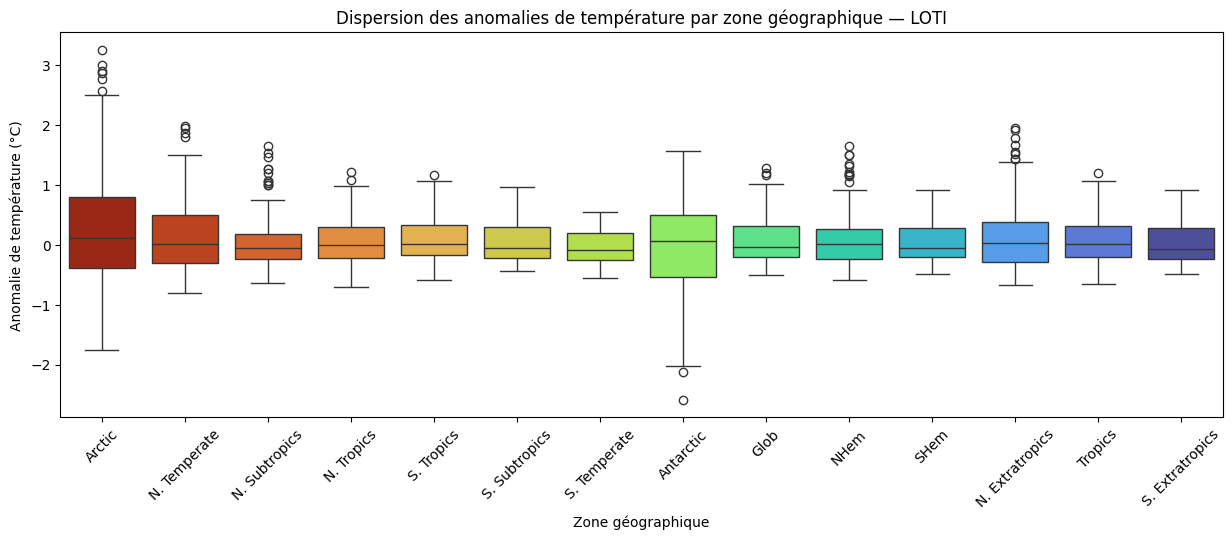

In [21]:
plt.figure(figsize = (15,5))
sns.boxplot(data = df_loti_long, y = "valeur", x = "zone", hue = "zone", order = ordre, palette = "turbo_r", legend = False, dodge = False)
plt.xticks(rotation=45)

plt.title("Dispersion des anomalies de température par zone géographique — LOTI")
plt.ylabel("Anomalie de température (°C)")
plt.xlabel("Zone géographique")

plt.show()


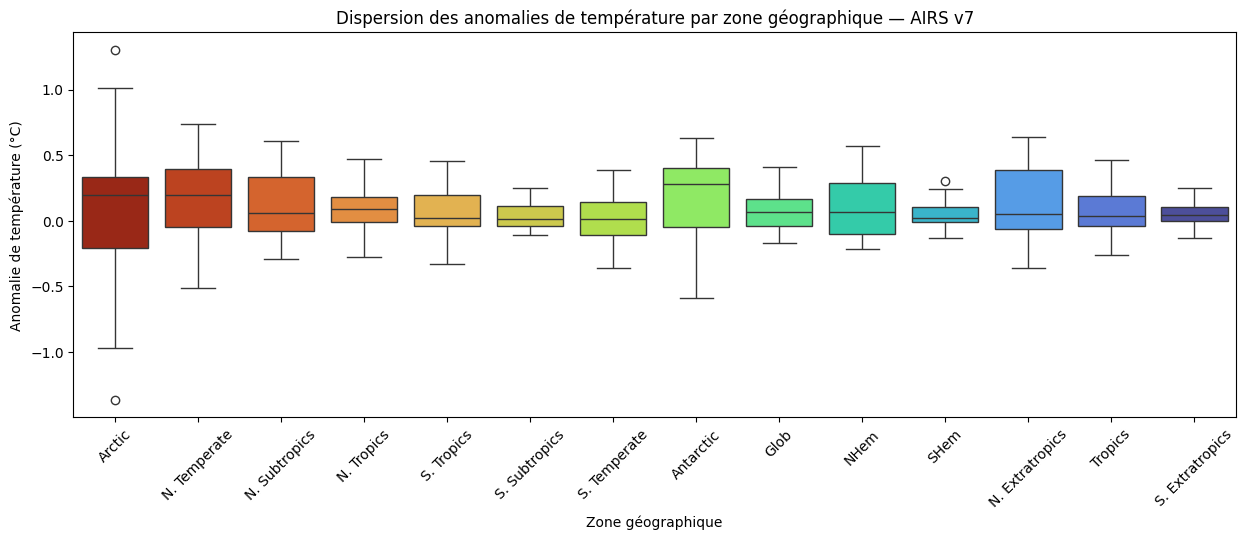

In [22]:
plt.figure(figsize = (15,5))
sns.boxplot(data = df_airs_v7_long, y = "valeur", x = "zone", hue = "zone", order = ordre, palette = "turbo_r", legend = False, dodge = False)
plt.xticks(rotation=45)

plt.title("Dispersion des anomalies de température par zone géographique — AIRS v7")
plt.ylabel("Anomalie de température (°C)")
plt.xlabel("Zone géographique")

plt.show()

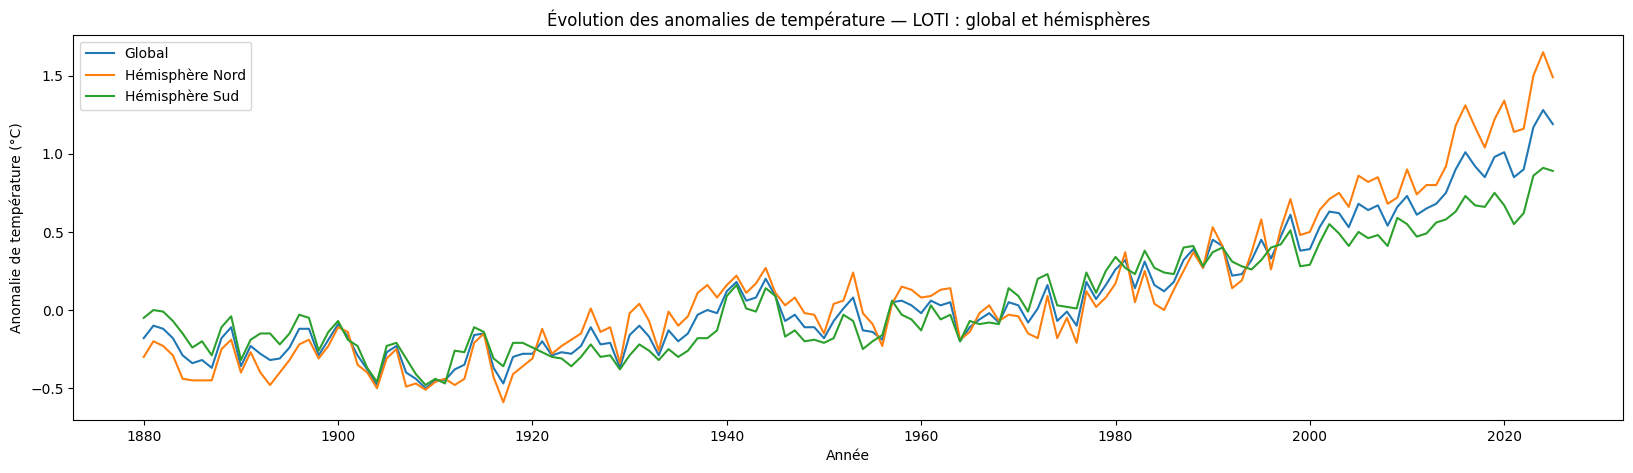

In [23]:
plt.figure(figsize=(20, 5))

plt.plot(df_loti["Glob"], label="Global")
plt.plot(df_loti["NHem"], label="Hémisphère Nord")
plt.plot(df_loti["SHem"], label="Hémisphère Sud")

plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")
plt.title("Évolution des anomalies de température — LOTI : global et hémisphères")

plt.legend()
plt.show()

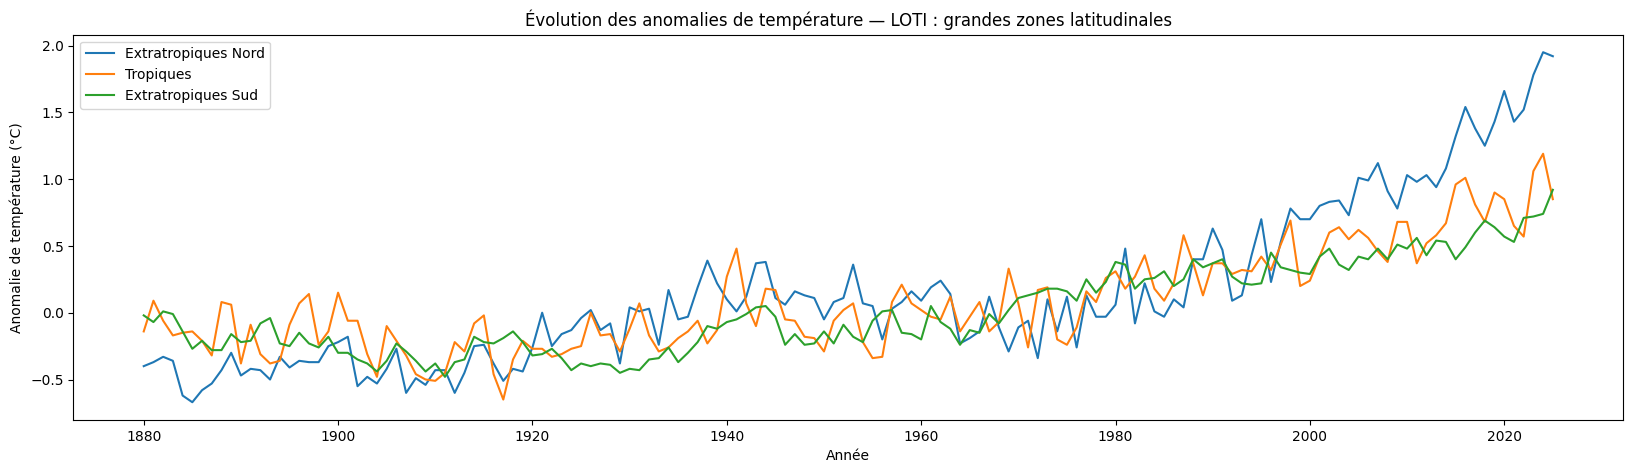

In [24]:
plt.figure(figsize=(20, 5))

plt.plot(df_loti["N. Extratropics"], label="Extratropiques Nord")
plt.plot(df_loti["Tropics"], label="Tropiques")
plt.plot(df_loti["S. Extratropics"], label="Extratropiques Sud")

plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")
plt.title("Évolution des anomalies de température — LOTI : grandes zones latitudinales")

plt.legend()
plt.show()

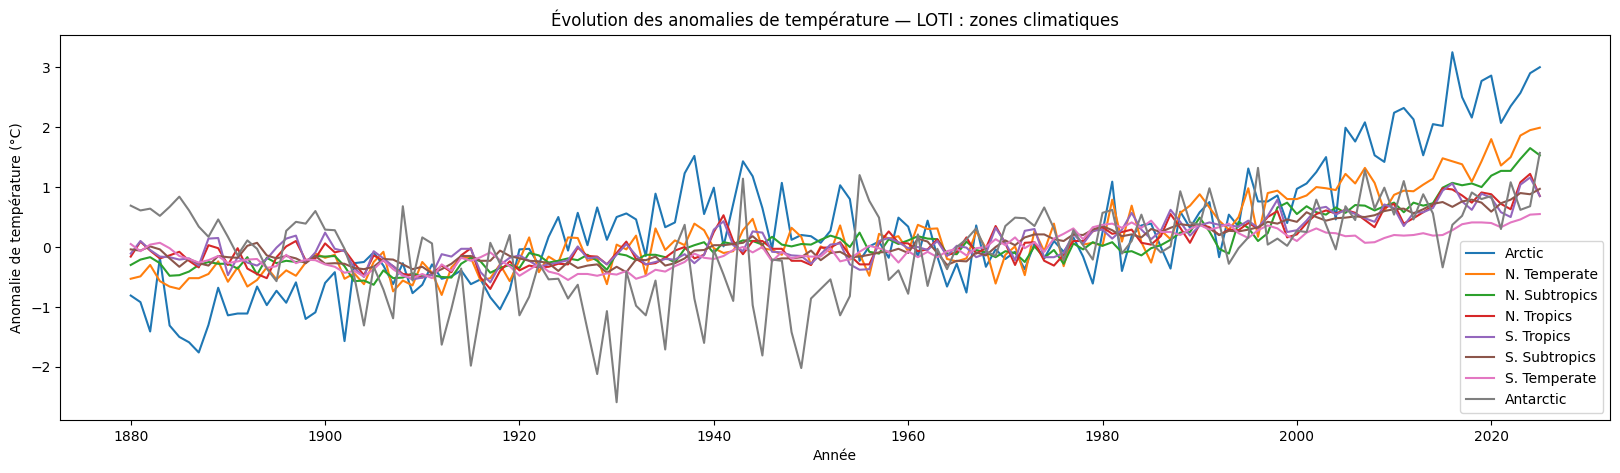

In [25]:
plt.figure(figsize = (20, 5))

plt.plot(df_loti["Arctic"], label = "Arctic")
plt.plot(df_loti["N. Temperate"], label = "N. Temperate")
plt.plot(df_loti["N. Subtropics"], label = "N. Subtropics")
plt.plot(df_loti["N. Tropics"], label = "N. Tropics")
plt.plot(df_loti["S. Tropics"], label = "S. Tropics")
plt.plot(df_loti["S. Subtropics"], label = "S. Subtropics")
plt.plot(df_loti["S. Temperate"], label = "S. Temperate")
plt.plot(df_loti["Antarctic"], label = "Antarctic")

plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")
plt.title("Évolution des anomalies de température — LOTI : zones climatiques")

plt.legend()
plt.show()

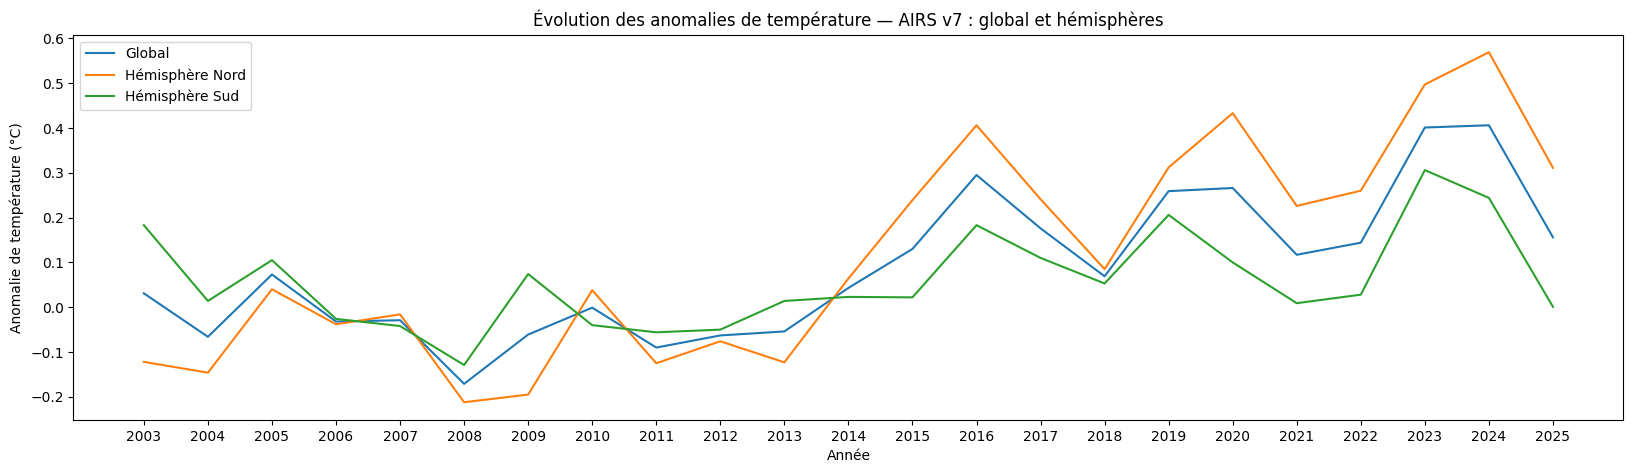

In [26]:
plt.figure(figsize=(20, 5))

plt.plot(df_airs_v7["Glob"], label="Global")
plt.plot(df_airs_v7["NHem"], label="Hémisphère Nord")
plt.plot(df_airs_v7["SHem"], label="Hémisphère Sud")

plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")
plt.title("Évolution des anomalies de température — AIRS v7 : global et hémisphères")

plt.legend()
plt.show()

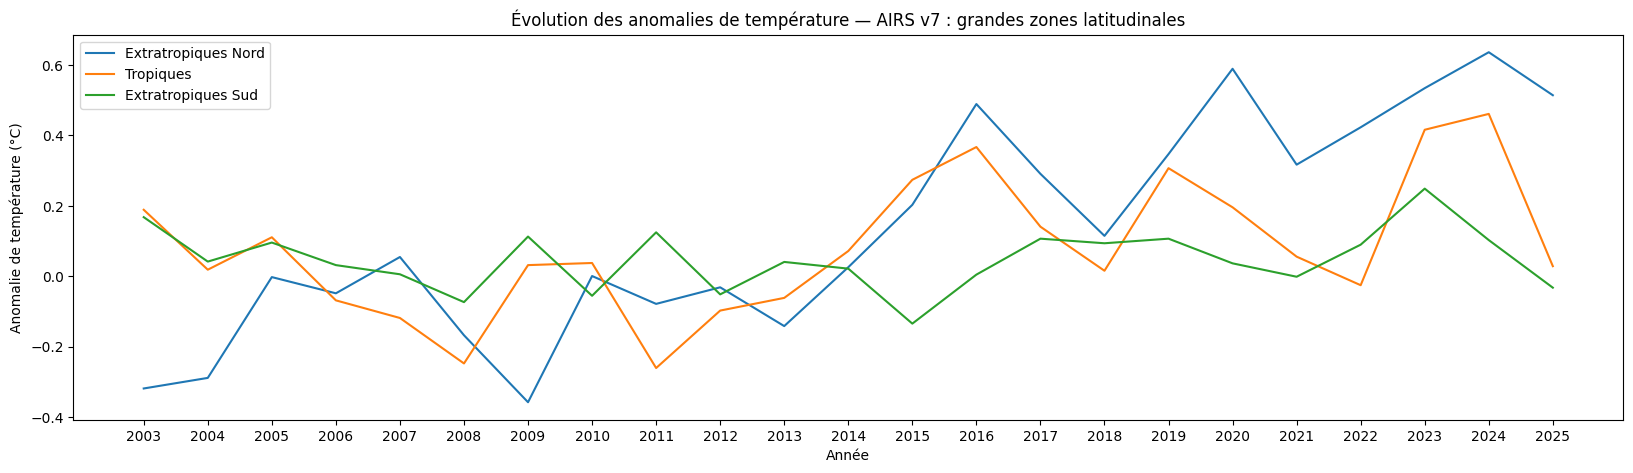

In [27]:
plt.figure(figsize = (20, 5))

plt.plot(df_airs_v7["N. Extratropics"], label="Extratropiques Nord")
plt.plot(df_airs_v7["Tropics"], label="Tropiques")
plt.plot(df_airs_v7["S. Extratropics"], label="Extratropiques Sud")

plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")
plt.title("Évolution des anomalies de température — AIRS v7 : grandes zones latitudinales")

plt.legend()
plt.show()

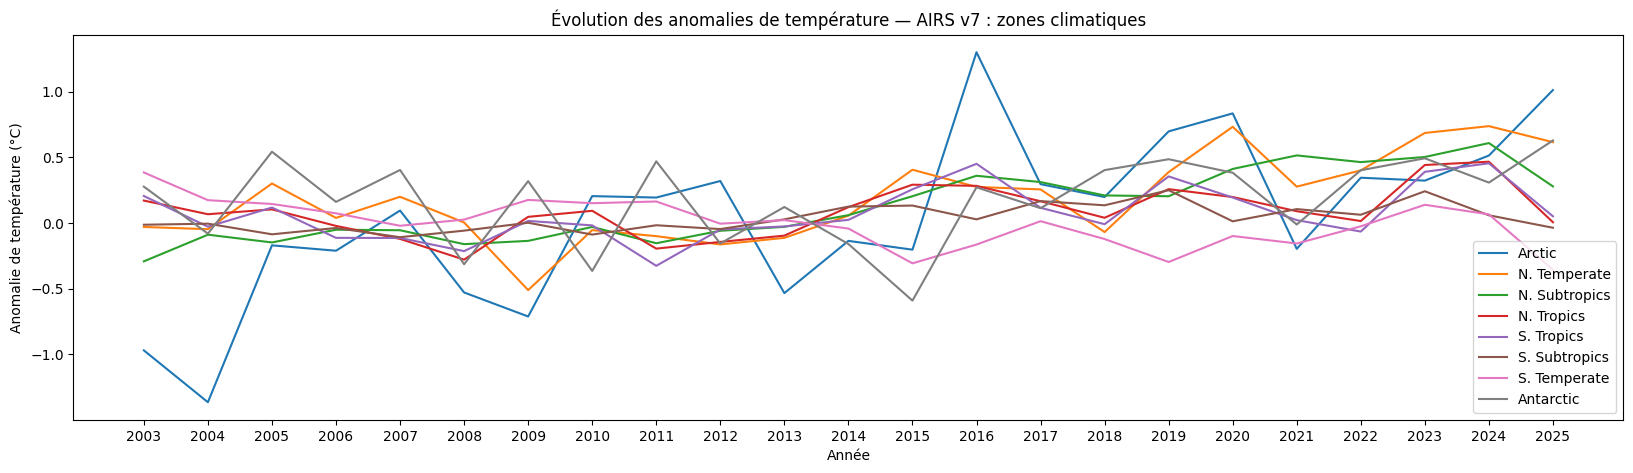

In [28]:
plt.figure(figsize = (20, 5))

plt.plot(df_airs_v7["Arctic"], label = "Arctic")
plt.plot(df_airs_v7["N. Temperate"], label = "N. Temperate")
plt.plot(df_airs_v7["N. Subtropics"], label = "N. Subtropics")
plt.plot(df_airs_v7["N. Tropics"], label = "N. Tropics")
plt.plot(df_airs_v7["S. Tropics"], label = "S. Tropics")
plt.plot(df_airs_v7["S. Subtropics"], label = "S. Subtropics")
plt.plot(df_airs_v7["S. Temperate"], label = "S. Temperate")
plt.plot(df_airs_v7["Antarctic"], label = "Antarctic")

plt.xlabel("Année")
plt.ylabel("Anomalie de température (°C)")
plt.title("Évolution des anomalies de température — AIRS v7 : zones climatiques")

plt.legend()
plt.show()

### Focus sur les régions polaires : l'amplification arctique

L'analyse des anomalies de température par zones climatiques met en évidence un comportement particulier des régions polaires. Dans les données LOTI, l'Arctique présente une augmentation des anomalies nettement plus importante que les autres zones climatiques, tandis que l'Antarctique montre une évolution plus irrégulière et moins marquée.

Ce phénomène, appelé **amplification arctique**, correspond à un réchauffement plus rapide de l'Arctique que de l'ensemble du globe. Il s'explique notamment par la diminution de la banquise : la disparition des surfaces glacées très réfléchissantes laisse apparaître des surfaces océaniques plus sombres, qui absorbent davantage le rayonnement solaire. Ce mécanisme de rétroaction lié à l'albédo contribue à accentuer le réchauffement de la région arctique.

L'Antarctique présente une dynamique différente, notamment en raison de sa configuration continentale, de son altitude et de son isolement par les circulations océaniques.

### Distribution des anomalies de température

Après l'étude de l'évolution temporelle des anomalies selon les différentes zones géographiques, nous nous intéressons maintenant à leur **distribution**.

Les histogrammes suivants permettent d'observer la répartition des anomalies de température à l'échelle **globale**, puis séparément pour les **hémisphères Nord et Sud**, et de comparer les résultats obtenus avec les jeux de données **LOTI** et **AIRS v7**.

Cette analyse est ensuite complétée par l'étude de la relation entre les anomalies observées dans les deux hémisphères.

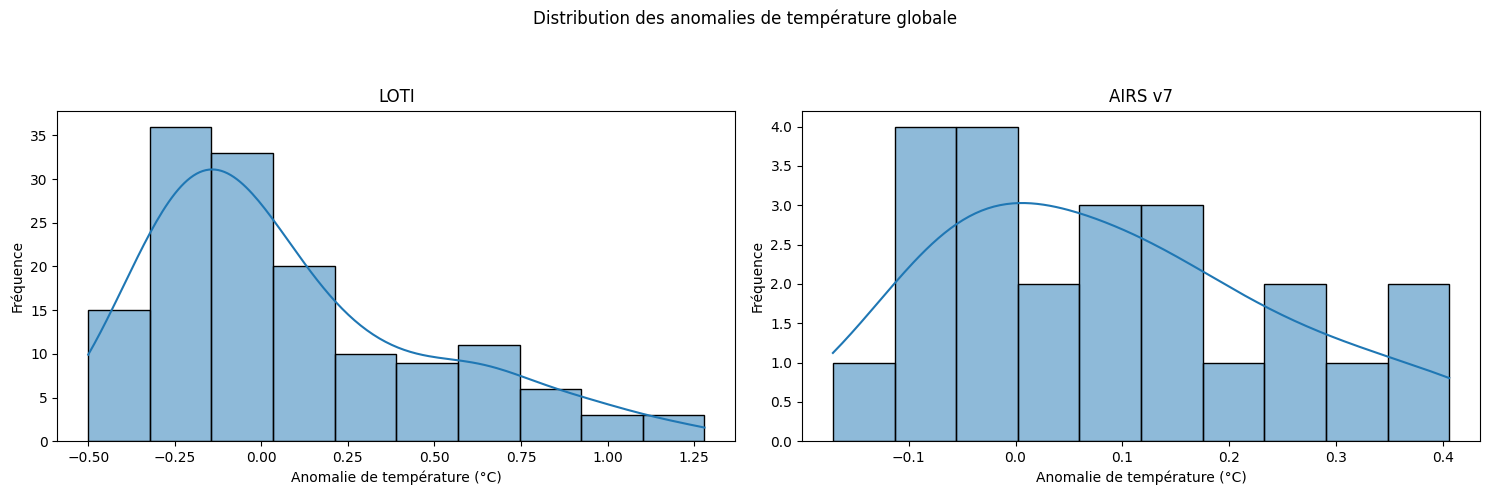

In [29]:
plt.figure(figsize=(15, 5))

plt.suptitle("Distribution des anomalies de température globale")

plt.subplot(121)
sns.histplot(data=df_loti["Glob"], bins=10, kde=True)
plt.title("LOTI")
plt.xlabel("Anomalie de température (°C)")
plt.ylabel("Fréquence")

plt.subplot(122)
sns.histplot(data=df_airs_v7["Glob"], bins=10, kde=True)
plt.title("AIRS v7")
plt.xlabel("Anomalie de température (°C)")
plt.ylabel("Fréquence")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

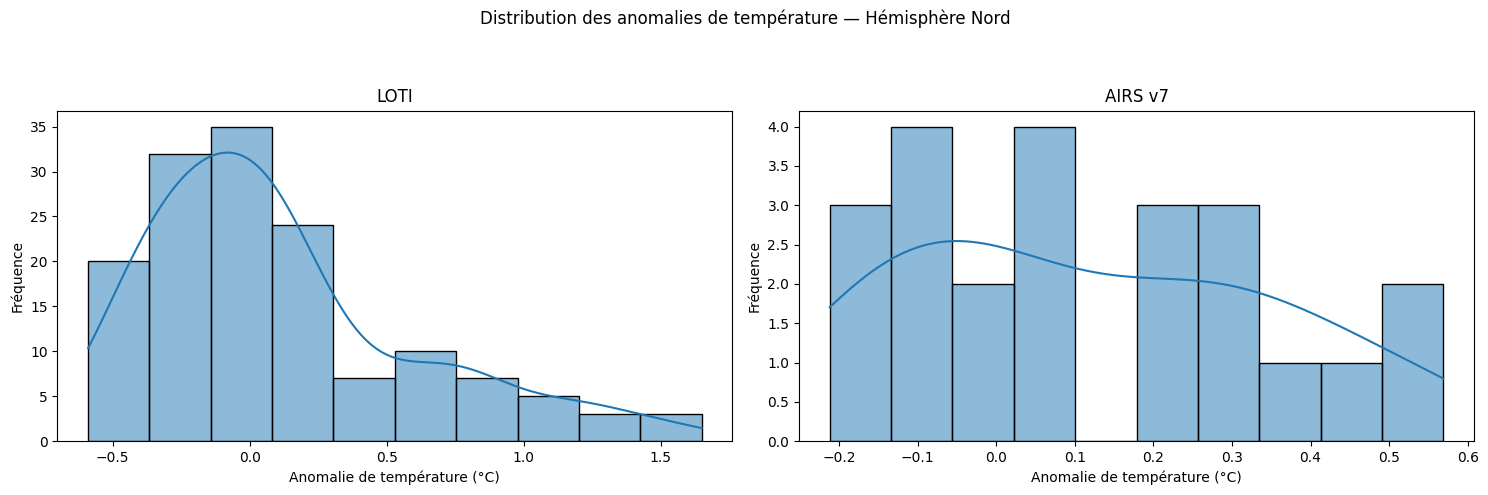

In [30]:
plt.figure(figsize=(15, 5))

plt.suptitle("Distribution des anomalies de température — Hémisphère Nord")

plt.subplot(121)
sns.histplot(data=df_loti["NHem"], bins=10, kde=True)
plt.title("LOTI")
plt.xlabel("Anomalie de température (°C)")
plt.ylabel("Fréquence")

plt.subplot(122)
sns.histplot(data=df_airs_v7["NHem"], bins=10, kde=True)
plt.title("AIRS v7")
plt.xlabel("Anomalie de température (°C)")
plt.ylabel("Fréquence")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

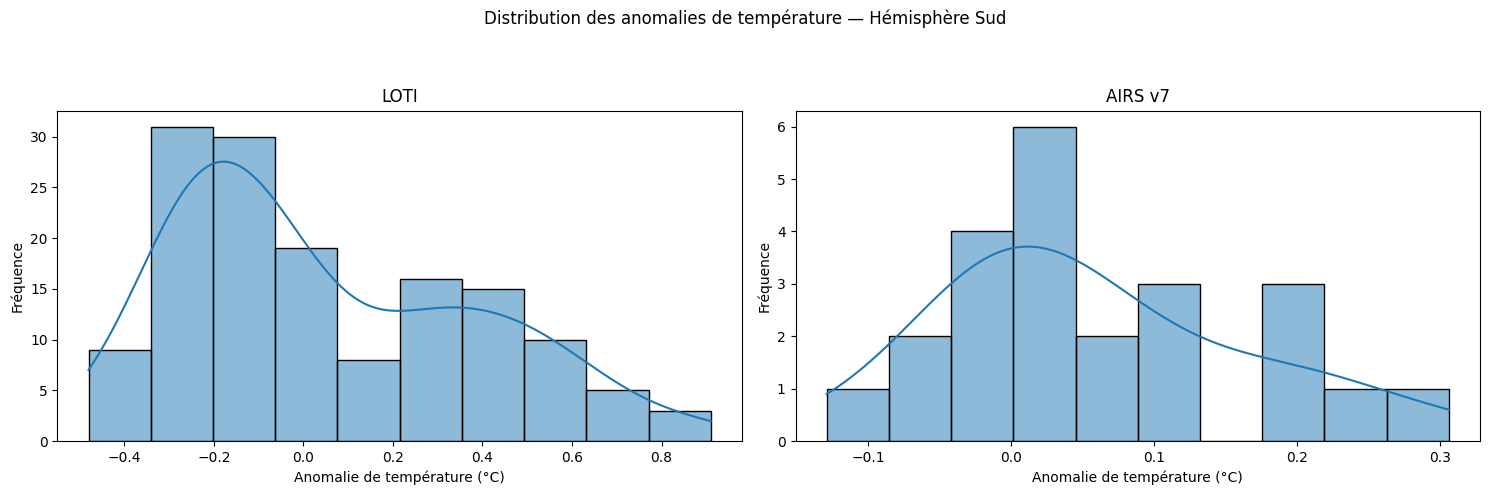

In [31]:
plt.figure(figsize=(15, 5))

plt.suptitle("Distribution des anomalies de température — Hémisphère Sud")

plt.subplot(121)
sns.histplot(data=df_loti["SHem"], bins=10, kde=True)
plt.title("LOTI")
plt.xlabel("Anomalie de température (°C)")
plt.ylabel("Fréquence")

plt.subplot(122)
sns.histplot(data=df_airs_v7["SHem"], bins=10, kde=True)
plt.title("AIRS v7")
plt.xlabel("Anomalie de température (°C)")
plt.ylabel("Fréquence")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

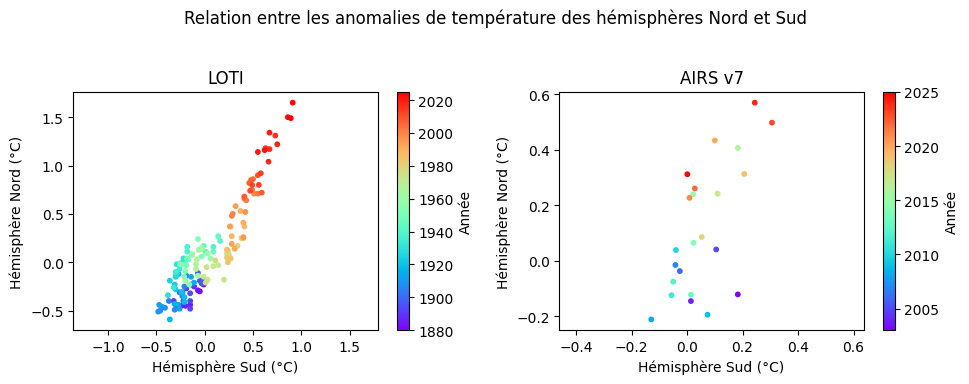

In [32]:
plt.figure(figsize=(10, 4))

plt.suptitle("Relation entre les anomalies de température des hémisphères Nord et Sud")

# LOTI
plt.subplot(121)

scatter1 = plt.scatter(df_loti["SHem"], df_loti["NHem"], s=10, cmap="rainbow", c=df_loti.index.astype(int))

plt.axis("equal")
plt.xlabel("Hémisphère Sud (°C)")
plt.ylabel("Hémisphère Nord (°C)")
plt.title("LOTI")

plt.colorbar(scatter1, label="Année")


# AIRS v7
plt.subplot(122)

scatter2 = plt.scatter(df_airs_v7["SHem"], df_airs_v7["NHem"], s=10, cmap="rainbow", c=df_airs_v7.index.astype(int))

plt.axis("equal")
plt.xlabel("Hémisphère Sud (°C)")
plt.ylabel("Hémisphère Nord (°C)")
plt.title("AIRS v7")

plt.colorbar(scatter2, label="Année")


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [33]:
df_loti[["SHem","NHem"]].corr()

,SHem,NHem
SHem,1.000000,0.915006
NHem,0.915006,1.000000


In [34]:
df_airs_v7[["SHem","NHem"]].corr()

,SHem,NHem
SHem,1.000000,0.660321
NHem,0.660321,1.000000


In [35]:
df_loti_annee_airsv7 = df_loti.loc[df_airs_v7.index.astype(int)]

In [36]:
df_loti_annee_airsv7[["SHem", "NHem"]].corr()

,SHem,NHem
SHem,1.000000,0.931334
NHem,0.931334,1.000000


### Corrélation entre les hémisphères Nord et Sud

Les données **LOTI** montrent une **très forte corrélation positive** entre les anomalies de température des hémisphères Nord et Sud (**r = 0,915**).  
Les deux hémisphères suivent donc globalement une évolution similaire au cours du temps.

La corrélation observée avec **AIRS v7** est plus modérée (**r = 0,660**).

Afin de vérifier si cette différence pouvait être liée à la période d'observation beaucoup plus courte d'AIRS v7, la corrélation de LOTI a également été recalculée uniquement sur les **23 années communes aux deux jeux de données**.

Sur cette même période, la corrélation LOTI atteint **r = 0,931**.

> **La différence observée entre LOTI et AIRS v7 ne semble donc pas s'expliquer uniquement par la longueur des séries temporelles.**

In [37]:
df_loti_annee_airsv7[["SHem","NHem"]].describe()

,SHem,NHem
count,23.000000,23.000000
mean,0.605652,1.030435
std,0.145472,0.290524
min,0.410000,0.660000
25%,0.490000,0.800000
50%,0.580000,0.920000
75%,0.670000,1.200000
max,0.910000,1.650000


In [38]:
df_airs_v7[["SHem","NHem"]].describe()

,SHem,NHem
count,23.000000,23.000000
mean,0.057913,0.116000
std,0.107755,0.234842
min,-0.129000,-0.212000
25%,-0.012500,-0.099000
50%,0.023000,0.064000
75%,0.107500,0.285500
max,0.306000,0.569000


In [39]:
diff_loti = df_loti_annee_airsv7["NHem"] - df_loti_annee_airsv7["SHem"]
diff_airs = df_airs_v7["NHem"] - df_airs_v7["SHem"]

print(diff_loti.describe())
print(diff_airs.describe())

print(diff_loti.std())
print(diff_airs.std())

count    23.000000
mean      0.424783
std       0.163842
min       0.130000
25%       0.290000
50%       0.370000
75%       0.565000
max       0.740000
dtype: float64
count    23.000000
mean      0.058087
std       0.182599
min      -0.305000
25%      -0.067000
50%       0.041000
75%       0.217000
max       0.333000
dtype: float64
0.16384220693918752
0.18259914194846646


### Écart entre les deux hémisphères

La forte corrélation observée entre les hémisphères Nord et Sud ne signifie pas que leurs anomalies de température sont identiques.

Sur la période commune aux deux jeux de données :

- **LOTI** présente un écart moyen d'environ **+0,42 °C** entre l'hémisphère Nord et l'hémisphère Sud ;
- **AIRS v7** présente un écart moyen beaucoup plus faible, d'environ **+0,06 °C**.

Pour LOTI, l'anomalie de température est donc en moyenne **plus élevée dans l'hémisphère Nord que dans l'hémisphère Sud**.

AIRS v7 montre quant à lui un écart moyen plus faible, avec davantage de variations dans le sens de cet écart selon les années.

> **Les deux sources mettent ainsi en évidence des comportements différents dans la représentation des écarts de température entre les deux hémisphères.**

#### Évolution de l'écart Nord–Sud

Afin de compléter cette comparaison, l'écart entre les anomalies de température de l'hémisphère Nord et de l'hémisphère Sud est représenté **année par année** sur la période commune à LOTI et AIRS v7.

Une valeur **positive** indique une anomalie plus élevée dans l'hémisphère Nord, tandis qu'une valeur **négative** indique une anomalie plus élevée dans l'hémisphère Sud.

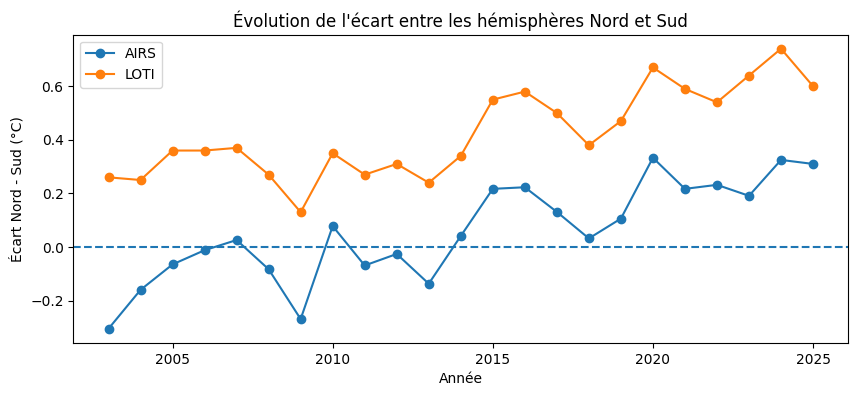

In [40]:
years = df_airs_v7.index.astype(int)

plt.figure(figsize=(10,4))

plt.plot(years, df_airs_v7["NHem"] - df_airs_v7["SHem"], marker="o", label="AIRS")

plt.plot(years, df_loti_annee_airsv7["NHem"] - df_loti_annee_airsv7["SHem"], marker="o", label="LOTI")

plt.axhline(0, ls="--")

plt.title("Évolution de l'écart entre les hémisphères Nord et Sud")
plt.xlabel("Année")
plt.ylabel("Écart Nord - Sud (°C)")

plt.legend()
plt.show()

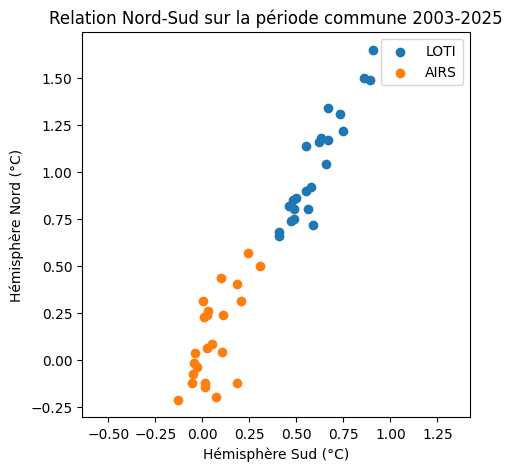

In [41]:
plt.figure(figsize=(5, 5))

plt.scatter(df_loti_annee_airsv7["SHem"], df_loti_annee_airsv7["NHem"], label="LOTI")

plt.scatter(df_airs_v7["SHem"], df_airs_v7["NHem"], label="AIRS")

plt.legend()
plt.xlabel("Hémisphère Sud (°C)")
plt.ylabel("Hémisphère Nord (°C)")
plt.title("Relation Nord-Sud sur la période commune 2003-2025")
plt.axis("equal")
plt.show()

### Corrélation entre les différentes zones climatiques

Afin d'approfondir la comparaison entre les jeux de données **LOTI** et **AIRS v7**, nous étudions les corrélations entre les anomalies de température des différentes zones climatiques, de l'Arctique à l'Antarctique.

Les matrices de corrélation permettent d'observer si les variations de température enregistrées dans les différentes régions évoluent de manière similaire.

In [42]:
df_loti_Earth1 = df_loti[["Arctic", "N. Temperate", "N. Subtropics", "N. Tropics", "S. Tropics", "S. Subtropics", "S. Temperate", "Antarctic"]]
df_loti_subtropics = df_loti[["N. Subtropics", "S. Subtropics"]]
df_loti_temperate = df_loti[["N. Temperate", "S. Temperate"]]
df_loti_tropics = df_loti[["N. Tropics", "S. Tropics"]]
df_loti_poles = df_loti[["Arctic", "Antarctic"]]

df_airs_v7_Earth1 = df_airs_v7[["Arctic", "N. Temperate", "N. Subtropics", "N. Tropics", "S. Tropics", "S. Subtropics", "S. Temperate", "Antarctic"]]

df_airs_v7_poles = df_airs_v7[["Arctic", "Antarctic"]]

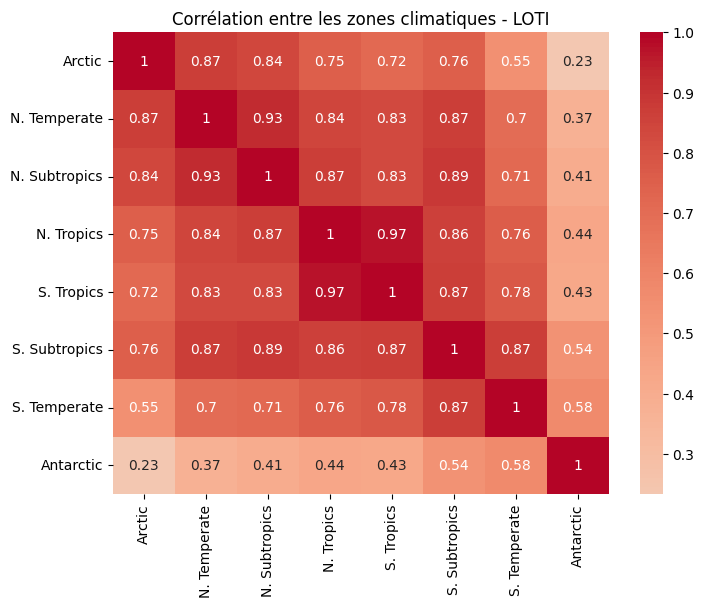

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(df_loti_Earth1.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Corrélation entre les zones climatiques - LOTI")
plt.show()

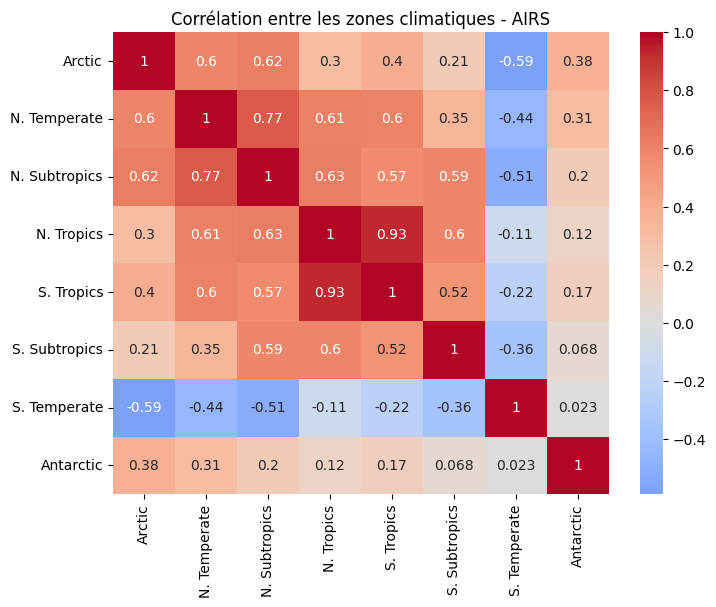

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(df_airs_v7_Earth1.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Corrélation entre les zones climatiques - AIRS")
plt.show()

### Comparaison des zones climatiques Nord / Sud

Afin de préciser les résultats observés dans les matrices de corrélation, nous comparons les zones climatiques équivalentes des deux hémisphères.

Une attention particulière est d'abord portée aux **régions polaires**, pour lesquelles la corrélation entre l'Arctique et l'Antarctique est comparée entre **LOTI** et **AIRS v7**.

L'analyse est ensuite poursuivie avec **LOTI** en comparant les zones tropicales, subtropicales et tempérées des hémisphères Nord et Sud, afin d'observer l'évolution de leur niveau de corrélation.

In [45]:
display(df_loti_poles.corr())
print("--------------------")
display(df_airs_v7_poles.corr())

,Arctic,Antarctic
Arctic,1.000000,0.232861
Antarctic,0.232861,1.000000


--------------------


,Arctic,Antarctic
Arctic,1.000000,0.383275
Antarctic,0.383275,1.000000


In [46]:
display(df_loti_tropics.corr())
print("--------------------")
display(df_loti_subtropics.corr())
print("--------------------")
display(df_loti_temperate.corr())


,N. Tropics,S. Tropics
N. Tropics,1.000000,0.968691
S. Tropics,0.968691,1.000000


--------------------


,N. Subtropics,S. Subtropics
N. Subtropics,1.000000,0.885707
S. Subtropics,0.885707,1.000000


--------------------


,N. Temperate,S. Temperate
N. Temperate,1.00000,0.69585
S. Temperate,0.69585,1.00000


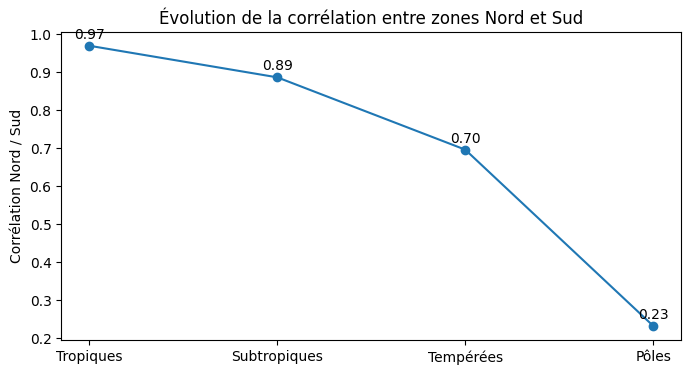

In [47]:
zones2 = ["Tropiques", "Subtropiques", "Tempérées", "Pôles"]
corrs = [0.969, 0.886, 0.696, 0.233]

plt.figure(figsize=(8,4))
plt.plot(zones2, corrs, marker="o")
plt.ylabel("Corrélation Nord / Sud")
plt.title("Évolution de la corrélation entre zones Nord et Sud")
plt.grid(False)

for x, y in zip(zones2, corrs):
    plt.text(x, y + 0.02, f"{y:.2f}", ha="center")

plt.show()

#### Interprétation des corrélations Nord / Sud

La comparaison met en évidence une diminution progressive de la corrélation entre les zones climatiques équivalentes des deux hémisphères lorsque l'on se rapproche des pôles.

Les **zones tropicales** présentent une très forte corrélation (**0,97**), suivies des **zones subtropicales** (**0,89**) et des **zones tempérées** (**0,70**). À l'inverse, la corrélation entre l'**Arctique et l'Antarctique** est beaucoup plus faible (**0,23**).

Ces résultats montrent que les variations de température sont fortement liées entre les deux hémisphères dans les zones tropicales et subtropicales, tandis que les régions polaires présentent des évolutions beaucoup plus différenciées.

Cette observation est cohérente avec les particularités climatiques des régions polaires évoquées précédemment, notamment le phénomène d'**amplification arctique**, qui contribue à une évolution différente des températures entre l'Arctique et l'Antarctique.

In [48]:
df_co2_world = pd.read_csv("../data/co2_world.csv", index_col = 0)

In [49]:
df_co2_world.info()

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 1880 to 2024
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   population                   145 non-null    float64
 1   gdp                          18 non-null     float64
 2   co2                          145 non-null    float64
 3   co2_per_capita               145 non-null    float64
 4   co2_including_luc            145 non-null    float64
 5   cumulative_co2               145 non-null    float64
 6   coal_co2                     145 non-null    float64
 7   oil_co2                      145 non-null    float64
 8   gas_co2                      143 non-null    float64
 9   energy_per_capita            60 non-null     float64
 10  primary_energy_consumption   60 non-null     float64
 11  total_ghg                    145 non-null    float64
 12  methane                      145 non-null    float64
 13  nitrous_oxide              

## Émissions de CO₂ et évolution des températures

Après avoir étudié l'évolution des anomalies de température et leurs différences selon les zones climatiques, nous nous intéressons maintenant à l'évolution des **émissions mondiales de CO₂**.

L'objectif est d'observer leur évolution dans le temps, puis d'étudier leur relation avec les anomalies de température mesurées par **LOTI**.

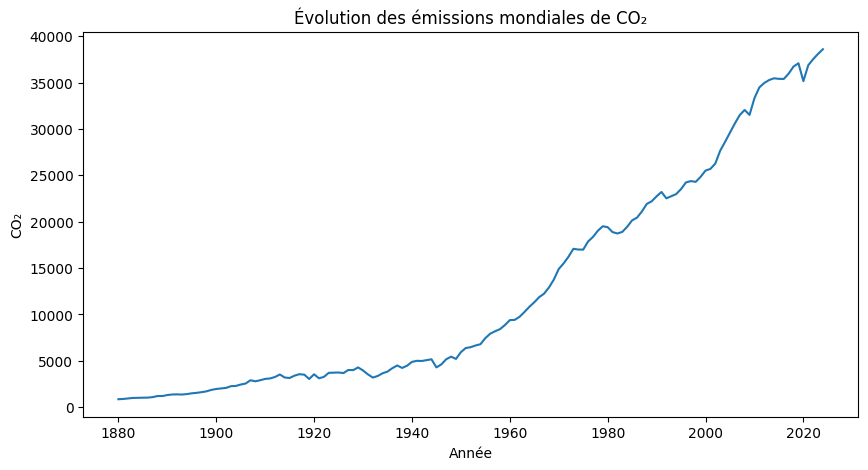

In [50]:
plt.figure(figsize=(10,5))
plt.plot(df_co2_world.index, df_co2_world["co2"])

plt.title("Évolution des émissions mondiales de CO₂")
plt.xlabel("Année")
plt.ylabel("CO₂")
plt.grid(False)
plt.show()

### Évolution des émissions mondiales de CO₂

Les émissions mondiales de CO₂ présentent une **tendance générale fortement croissante** depuis 1880, avec une accélération particulièrement marquée à partir de la seconde moitié du XXᵉ siècle.

Quelques diminutions ponctuelles sont visibles au cours de la période, mais elles ne remettent pas en cause la tendance de fond.

Nous allons maintenant étudier si cette évolution est associée à celle des anomalies de température globale.

### Relation entre les émissions de CO₂ et les anomalies de température

Les données OWID contiennent plusieurs indicateurs liés aux émissions de gaz à effet de serre et à leur contribution estimée à l'évolution des températures.

Une première analyse des corrélations permet d'observer les relations entre ces différentes variables.

Afin de confronter ces données aux températures étudiées précédemment, les émissions mondiales de **CO₂** sont ensuite associées aux anomalies de température globale issues de **LOTI** sur les années communes aux deux jeux de données.

In [51]:
df_co2_world[["co2", "total_ghg", "temperature_change_from_co2", "temperature_change_from_ghg"]].corr()

,co2,total_ghg,temperature_change_from_co2,temperature_change_from_ghg
co2,1.000000,0.993789,0.992861,0.994296
total_ghg,0.993789,1.000000,0.990543,0.994272
temperature_change_from_co2,0.992861,0.990543,1.000000,0.999238
temperature_change_from_ghg,0.994296,0.994272,0.999238,1.000000


In [52]:
df_merge = pd.concat([df_loti["Glob"], df_co2_world["co2"]], axis=1)

df_merge.columns = ["Temperature", "CO2"]

In [53]:
df_merge.corr()

,Temperature,CO2
Temperature,1.000000,0.935052
CO2,0.935052,1.000000


#### Résultat

La corrélation entre les émissions mondiales de **CO₂** et les anomalies de température globale **LOTI** est de **0,94**.

Cette valeur indique une **très forte corrélation positive** : sur la période étudiée, l'augmentation des émissions mondiales de CO₂ est associée à une augmentation des anomalies de température globale.

La corrélation met en évidence une forte relation statistique entre les deux variables. Elle ne constitue toutefois pas, à elle seule, une démonstration de causalité.

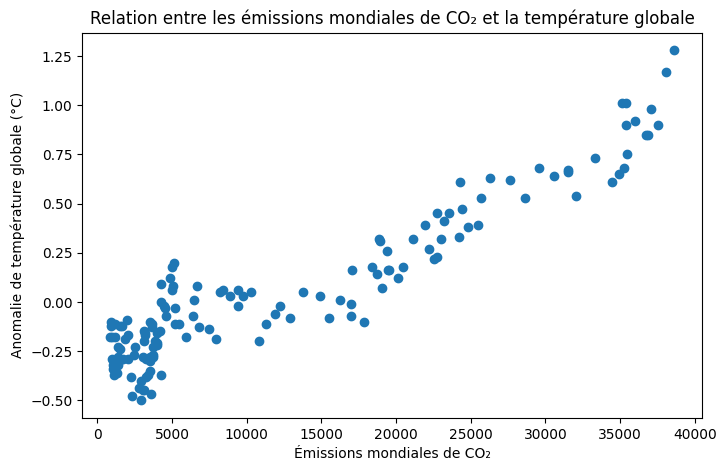

In [54]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_merge["CO2"],
    df_merge["Temperature"]
)

plt.title("Relation entre les émissions mondiales de CO₂ et la température globale")
plt.xlabel("Émissions mondiales de CO₂")
plt.ylabel("Anomalie de température globale (°C)")

plt.show()

### Visualisation de la relation

Le nuage de points confirme visuellement la relation positive mise en évidence par le coefficient de corrélation : les anomalies de température globale tendent à augmenter lorsque les émissions mondiales de CO₂ augmentent.

Cette analyse clôt la phase exploratoire des données. Les jeux de données préparés peuvent maintenant être exportés afin d'être réutilisés dans la suite du projet et mis à disposition des autres membres de l'équipe.

## Export des données préparées

À l'issue des étapes de nettoyage, de transformation et d'analyse, les jeux de données préparés sont exportés au format **CSV**.

Ces fichiers permettent de disposer de versions nettoyées et directement exploitables pour la poursuite du projet dans les notebooks suivants. Ils ont également été mis à disposition des autres membres de l'équipe afin de faciliter le travail collaboratif et d'assurer l'utilisation de données préparées de manière homogène.

In [55]:
df_loti.to_csv("../data/df_zc_loti_clean.csv")

df_airs_v7.to_csv("../data/df_zc_airs_v7_clean.csv")

df_ghcn_ersst.to_csv("../data/df_zc_ghcn_ersst_clean.csv")

In [56]:
df_loti_long.to_csv("../data/df_zc_loti_melt_clean.csv")

df_airs_v7_long.to_csv("../data/df_zc_airs_v7_melt_clean.csv")

df_ghcn_ersst_long.to_csv("../data/df_zc_ghcn_ersst_melt_clean.csv")